<a href="https://colab.research.google.com/github/JohanImbolBioDev/Descargar_informarmacion_GenBank/blob/main/MultiSirleyLocus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MultiLocusPocho

Este notebook lo creé con la intención de poder realizar la mejor filogenia de especies Scarabaeinae que se encuentran en el territorio Colombiano, utilizando toda la información posible que encontrara en GenBank. Al ejecutar el notebook, lo que hará es descargar toda la metadata necesaria para poder realizar un filtrado de las secuencias. El objetivo es tener la mayor cantidad de secuencias de distintos genes de un mismo espécimen para poder realizar la mejor matriz de datos genéticos para poder crear esa filogenia multilocus.

Al ejecutar todo el código, obtendrá un TSV con metadata importante por cada búsqueda, con la cual podrá realizar el filtrado de las secuencias.

Finalmente, encontrará un framework de cómo podría realizar esa limpieza para su grupo de elección y cómo visualizar la información que hay sobre su grupo en GenBank.

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.7 MB/s eta 0:00:00


In [ ]:
from Bio import Entrez
import re
import csv
import sys
import time

In [ ]:
BATCH_SIZE = 100

GENE_PATTERNS = {
    "COI": [
        r"\bCOI\b",
        r"\bCO1\b",
        r"\bCOXI\b",
        r"\bCOX1\b",
        r"cytochrome c oxidase subunit i",
        r"cytochrome oxidase i",
    ],
    "16S": [
        r"\b16S\b",
        r"16S ribosomal RNA",
    ],
    "18S": [
        r"\b18S\b",
        r"18S ribosomal RNA",
    ],
    "28SD2": [
        r"28S.*D2",
        r"28SD2",
    ],
    "28SD3": [
        r"28S.*D3",
        r"28SD3",
    ],
    "CAD": [
        r"\bCAD\b",
        r"carbamoylphosphate synthetase",
    ],
    "TP1": [
        r"\bTP1\b",
        r"\bTPI\b",
        r"topoisomerase I",
    ],
    "WG": [
        r"\bWG\b",
        r"wingless",
    ],
}


def normalize_gene(text):

    for gene, patterns in GENE_PATTERNS.items():

        for pattern in patterns:

            if re.search(pattern, text, re.IGNORECASE):
                return gene

    return None

def extract_accession(record):

    m = re.search(r"VERSION\s+([A-Z0-9_.]+)", record)

    if m:
        return m.group(1)

    return None


def extract_species(record):

    m = re.search(r"ORGANISM\s+([^\n]+)", record)

    if m:
        return m.group(1).strip()

    return None


def extract_sample_id(record):

    patterns = [
        r'/specimen_voucher="([^"]+)"',
        r'/voucher="([^"]+)"',
        r'/isolate="([^"]+)"',
        r'/strain="([^"]+)"',
    ]

    for p in patterns:

        m = re.search(p, record, re.IGNORECASE)

        if m:
            return m.group(1).strip()

    return None


def extract_genes(record):

    genes = set()

    cds_blocks = re.findall(
        r"CDS\s+.*?(?=\n\s{5}\S|\Z)",
        record,
        re.DOTALL
    )

    gene_blocks = re.findall(
        r"gene\s+.*?(?=\n\s{5}\S|\Z)",
        record,
        re.DOTALL
    )

    blocks = cds_blocks + gene_blocks

    for block in blocks:

        fields = []

        for qualifier in [
            "gene",
            "product",
            "note",
            "gene_synonym"
        ]:

            matches = re.findall(
                rf'/{qualifier}="([^"]+)"',
                block,
                re.IGNORECASE
            )

            fields.extend(matches)

        text = " ".join(fields)

        gene = normalize_gene(text)

        if gene:
            genes.add(gene)

    return genes


def parse_record(record):

    accession = extract_accession(record)

    if accession is None:
        return []

    species = extract_species(record)

    sample_id = extract_sample_id(record)

    if sample_id is None:
        sample_id = accession

    genes = extract_genes(record)

    rows = []

    for gene in genes:

        rows.append(
            {
                "accession": accession,
                "species": species,
                "sample_id": sample_id,
                "gene": gene,
            }
        )

    return rows

In [ ]:

if API_KEY:
    Entrez.api_key = API_KEY

BATCH_SIZE = 100


# =========================
# NCBI
# =========================

def search_species(species):

    handle = Entrez.esearch(
        db="nucleotide",
        term=f'"{species}"[ORGN]',
        usehistory="y",
        retmax=0
    )

    result = Entrez.read(handle)

    return (
        int(result["Count"]),
        result["WebEnv"],
        result["QueryKey"]
    )


def fetch_batch(webenv, query_key, start, batch_size):

    handle = Entrez.efetch(
        db="nucleotide",
        rettype="gb",
        retmode="text",
        webenv=webenv,
        query_key=query_key,
        retstart=start,
        retmax=batch_size
    )

    return handle.read()


# =========================
# PARSER GENBANK
# =========================

def extract_scientificName(record):
  m = re.search(
        r'/organism="([^"]+)"',
        record,
        flags=re.IGNORECASE
    )

  return m.group(1).strip() if m else ""


def extract_accession(record):

    m = re.search(
        r"VERSION\s+([A-Z0-9_.]+)",
        record
    )

    return m.group(1) if m else ""

def extract_definition(record):

    try:
        definition = record.split(
            "DEFINITION", 1
        )[1].split(
            "ACCESSION", 1
        )[0]

        definition = " ".join(
            definition.split()
        )

        return definition

    except Exception:
        return ""


def extract_voucher(record):
    for field in ["specimen_voucher", "isolate"]:
        m = re.search(
            rf'/{field}="([^"]+)"',
            record,
            flags=re.IGNORECASE
        )
        if m:
            return m.group(1).strip()

    return ""


def extract_genes(record):

    genes = set()

    for gene in re.findall(
        r'/gene="([^"]+)"',
        record,
        flags=re.IGNORECASE
    ):
        genes.add(gene.strip())

    products = set()

    for product in re.findall(
        r'/product="([^"]+)"',
        record,
        flags=re.IGNORECASE
    ):
        products.add(product.strip())

    return (
        ";".join(sorted(genes)),
        ";".join(sorted(products))
    )

def extract_reference(record):

    authors = ""
    title = ""
    journal = ""
    pubmed = ""

    try:

        ref_block = record.split(
            "REFERENCE", 1
        )[1]

        next_ref = re.split(
            r"\nREFERENCE\s",
            ref_block,
            maxsplit=1
        )

        ref_block = next_ref[0]

    except Exception:

        return authors, title, journal, pubmed

    m = re.search(
        r"AUTHORS\s+(.+?)(?=\n\s{2,}[A-Z]|$)",
        ref_block,
        flags=re.DOTALL
    )

    if m:
        authors = " ".join(
            m.group(1).split()
        )

    m = re.search(
        r"TITLE\s+(.+?)(?=\n\s{2,}[A-Z]|$)",
        ref_block,
        flags=re.DOTALL
    )

    if m:
        title = " ".join(
            m.group(1).split()
        )

    m = re.search(
        r"JOURNAL\s+(.+?)(?=\n\s{2,}[A-Z]|$)",
        ref_block,
        flags=re.DOTALL
    )

    if m:
        journal = " ".join(
            m.group(1).split()
        )

    m = re.search(
        r"PUBMED\s+(\d+)",
        ref_block
    )

    if m:
        pubmed = m.group(1)

    return authors, title, journal, pubmed


def parse_record(record):

    accession = extract_accession(record)

    if not accession:
        return None

    scientificName = extract_scientificName(record)

    definition = extract_definition(record)

    voucher = extract_voucher(record)

    genes = extract_genes(record)

    authors, title, journal, pubmed = extract_reference(record)

    return {
        "scientificName": scientificName,
        "accession": accession,
        "definition": definition,
        "voucher": voucher,
        "genes": genes,
        "authors": authors,
        "title": title,
        "journal": journal,
        "pubmed": pubmed
    }


# =========================
# MAIN
# =========================

def collect_species(species, output_file="records.tsv"):

    print(f"\nBuscando: {species}")

    count, webenv, query_key = search_species(species)

    print(f"Registros encontrados: {count}")

    with open(
        output_file,
        "w",
        newline="",
        encoding="utf-8"
    ) as out:

        writer = csv.DictWriter(
            out,
            fieldnames=[
                "scientificName",
                "accession",
                "definition",
                "voucher",
                "genes",
                "authors",
                "title",
                "journal",
                "pubmed"
            ],
            delimiter="\t"
        )

        writer.writeheader()

        for start in range(
            0,
            count,
            BATCH_SIZE
        ):

            print(
                f"Descargando {start} - "
                f"{min(start+BATCH_SIZE,count)}"
            )

            text = fetch_batch(
                webenv,
                query_key,
                start,
                BATCH_SIZE
            )

            records = text.split("\n//")

            for record in records:

                data = parse_record(record)

                if data:
                    writer.writerow(data)

            time.sleep(0.11)

    print(
        f"\nArchivo generado: {output_file}"
    )

    return count, webenv, query_key

In [ ]:
collect_species("Digitonthophagus gazella", f"Digitonthophagus gazella.tsv")


Buscando: Digitonthophagus gazella
Registros encontrados: 162
Descargando 0 - 100
Descargando 100 - 162

Archivo generado: Digitonthophagus gazella.tsv


(162, 'MCID_6aa8cf0c1bff4e69d5039b46', '1')

# Exploración de los datos

In [ ]:
import pandas as pd

df = pd.read_csv(f"Digitonthophagus gazella.tsv", sep="\t")
df.head()

,scientificName,accession,definition,voucher,genes,authors,title,journal,pubmed
0,Digitonthophagus gazella,PX635594.1,Digitonthophagus gazella voucher MA_COL045 cyt...,MA_COL045,"('COX1', 'cytochrome c oxidase subunit I')","Pinzari,C.A., Gorresen,P.M., Peck,R.W. and Cou...",Dietary Composition and Diversity in an Endemi...,Acta Chiropt 28 (1) (2026) In press,NaN
1,Digitonthophagus gazella,PX635430.1,Digitonthophagus gazella voucher HA_COL004 cyt...,HA_COL004,"('COX1', 'cytochrome c oxidase subunit I')","Pinzari,C.A., Gorresen,P.M., Peck,R.W. and Cou...",Dietary Composition and Diversity in an Endemi...,Acta Chiropt 28 (1) (2026) In press,NaN
2,Digitonthophagus gazella,JASCIT000000000.1,"Digitonthophagus gazella isolate SAFR, whole g...",SAFR,"('', '')","Davidson,P.L. and Moczek,A.P.",Genome evolution and divergence in cis-regulat...,"PLoS Genet 20 (3), e1011165 (2024)",38442113.0
3,Digitonthophagus gazella,PX945226.1,Digitonthophagus gazella voucher (COX1) gene c...,(COX1) gene,"('COX1', 'cytochrome c oxidase subunit I')","alam,I., zaman,Q., Nawab,U., saleem ahmad,M. a...",Direct Submission,"Submitted (01-FEB-2026) Zoology, University of...",NaN
4,Digitonthophagus gazella,PQ504598.1,Digitonthophagus gazella voucher SPEC#5279 cyt...,SPEC#5279,"('COI', 'cytochrome oxidase subunit 1')","Gijsman,F., Pringle,R.M. and Miller,S.E.",Dung beetles of the Mpala Research Centre,Unpublished,NaN


In [ ]:
df.groupby(["voucher"])["title"].count().sort_values(ascending=False).head(10)

,title
voucher,
CSR142,81
Ont.cat.15.1,5
DTP2,3
Ont.cat.15.2,3
BMNH:669836,2
DTP1,2
BMNH:669837,2
BMNH:669865,2
BIOUG<CAN>:09BBCOL-0261,1


In [ ]:
df.groupby(["genes"])['voucher'].count().sort_values(ascending=False).head(10)

,voucher
genes,
"('COI', 'cytochrome oxidase subunit 1')",26
"('COX1', 'cytochrome c oxidase subunit I')",20
"('', '28S ribosomal RNA')",5
"('', '16S ribosomal RNA')",4
"('COI', 'cytochome oxidase subunit I')",3
"('cox1', 'cytochrome oxidase subunit I')",3
"('', '18S ribosomal RNA')",2
"('COI', 'cytochrome oxidase subunit I')",2
"('', '')",1


In [ ]:
df.loc[df["voucher"].isna()]

,scientificName,accession,definition,voucher,genes,authors,title,journal,pubmed
129,Digitonthophagus gazella,EU162450.1,Onthophagus gazella cytochrome c oxidase subun...,NaN,"('COI', 'cytochrome c oxidase subunit I')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
130,Digitonthophagus gazella,EU162408.1,Onthophagus gazella cytochrome c oxidase subun...,NaN,"('COII', 'cytochrome c oxidase subunit II')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
131,Digitonthophagus gazella,EU162362.1,Onthophagus gazella ARD1-like protein a (Ard1a...,NaN,"('Ard1a', 'ARD1-like protein a')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
132,Digitonthophagus gazella,EU162345.1,Onthophagus gazella neurofibromin 1 (Nf1) gene...,NaN,"('Nf1', 'neurofibromin 1')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
133,Digitonthophagus gazella,AY131918.1,Digitonthophagus gazella cytochrome oxidase su...,NaN,"('COI', 'cytochrome oxidase subunit I')","Monaghan,M.T., Inward,D.J., Hunt,T. and Vogler...",A molecular phylogenetic analysis of the Scara...,"Mol. Phylogenet. Evol. 45 (2), 674-692 (2007)",17656114.0
146,Digitonthophagus gazella,AY131563.1,Digitonthophagus gazella 16S ribosomal RNA gen...,NaN,"('', '16S ribosomal RNA')","Monaghan,M.T., Inward,D.J., Hunt,T. and Vogler...",A molecular phylogenetic analysis of the Scara...,"Mol. Phylogenet. Evol. 45 (2), 674-692 (2007)",17656114.0
147,Digitonthophagus gazella,HQ677814.1,Onthophagus gazella cytochrome oxidase subunit...,NaN,"('COII', 'cytochrome oxidase subunit II')","McCracken,G.F., Westbrook,J.K., Brown,V.A., El...",Bats track and exploit changes in insect pest ...,"PLoS ONE 7 (8), E43839 (2012)",22952782.0
148,Digitonthophagus gazella,EU162544.1,"Onthophagus gazella 16S ribosomal RNA gene, pa...",NaN,"('', '16S ribosomal RNA')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
149,Digitonthophagus gazella,EU162495.1,"Onthophagus gazella 28S ribosomal RNA gene, pa...",NaN,"('', '28S ribosomal RNA')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
155,Digitonthophagus gazella,DQ430936.1,"Onthophagus gazella 28S ribosomal RNA gene, pa...",NaN,"('', '28S ribosomal RNA')","Ocampo,F.C. and Hawks,D.C.",Molecular phylogenetics and evolution of the f...,Unpublished,NaN


In [ ]:
df.groupby(["genes"])["title"].count().sort_values(ascending=False).head(10)

,title
genes,
"('COI', 'cytochrome oxidase subunit 1')",26
"('COX1', 'cytochrome c oxidase subunit I')",20
"('', '28S ribosomal RNA')",9
"('', '16S ribosomal RNA')",6
"('COI', 'cytochrome oxidase subunit I')",3
"('', '18S ribosomal RNA')",3
"('COI', 'cytochome oxidase subunit I')",3
"('cox1', 'cytochrome oxidase subunit I')",3
"('', '')",1


# Scarabaeinae Colombia

In [ ]:
!wget /content/scarabaeinae_colombia.zip https://ipt.biodiversidad.co/sib/archive.do?r=scarabaeinae_colombia&v=1.1

/content/scarabaeinae_colombia.zip: Scheme missing.
--2026-09-15 04:52:38--  https://ipt.biodiversidad.co/sib/archive.do?r=scarabaeinae_colombia
Resolving ipt.biodiversidad.co (ipt.biodiversidad.co)... 51.38.48.143
Connecting to ipt.biodiversidad.co (ipt.biodiversidad.co)|51.38.48.143|:443... connected.
HTTP request sent, awaiting response... 200 
Length: unspecified [application/zip]
Saving to: ‘archive.do?r=scarabaeinae_colombia’

archive.do?r=scarab     [ <=>                ] 233.39K  --.-KB/s    in 0.04s   

2026-09-15 04:52:39 (5.46 MB/s) - ‘archive.do?r=scarabaeinae_colombia’ saved [238988]

FINISHED --2026-09-15 04:52:39--
Total wall clock time: 0.3s
Downloaded: 1 files, 233K in 0.04s (5.46 MB/s)


In [ ]:
!unzip /content/archive.do?r=scarabaeinae_colombia

Archive:  /content/archive.do?r=scarabaeinae_colombia
  inflating: speciesprofile.txt      
  inflating: typesandspecimen.txt    
  inflating: reference.txt           
  inflating: taxon.txt               
  inflating: eml.xml                 
  inflating: distribution.txt        
  inflating: meta.xml                


In [ ]:
import pandas as pd

especies = pd.read_csv("taxon.txt" , sep="\t")
especies['taxonRank'].unique()

array(['Familia', 'Subfamilia', 'Género', 'Especie', 'Subespecie',
       'Tribu', 'Subgénero'], dtype=object)

In [ ]:
especies = pd.read_csv("taxon.txt" , sep="\t")
especies['taxonRank'].unique()

array(['Familia', 'Subfamilia', 'Género', 'Especie', 'Subespecie',
       'Tribu', 'Subgénero'], dtype=object)

In [ ]:
especies = especies[especies['taxonRank'] == 'Especie']

In [ ]:
especies['genus'].nunique()

40

In [ ]:
especies['taxonRank'].unique()

array(['Especie'], dtype=object)

In [ ]:
especies.shape

(351, 26)

In [ ]:
taxas = especies['scientificName'].unique()

In [ ]:
!rm *.tsv

In [ ]:
Registros = pd.DataFrame(columns=["especie", "registros"])

for taxa in taxas:
  count, _, z = collect_species(taxa, f"{taxa}.tsv")
  Registros = pd.concat([Registros, pd.DataFrame([{"especie": taxa, "registros": count}])], ignore_index=True)


Buscando: Agamopus lampros
Registros encontrados: 0

Archivo generado: Agamopus lampros.tsv

Buscando: Andinocopris achamas
Registros encontrados: 0

Archivo generado: Andinocopris achamas.tsv

Buscando: Anisocanthon sericinus
Registros encontrados: 0

Archivo generado: Anisocanthon sericinus.tsv

Buscando: Anisocanthon villosus
Registros encontrados: 0

Archivo generado: Anisocanthon villosus.tsv

Buscando: Anomiopus cuprarius
Registros encontrados: 0

Archivo generado: Anomiopus cuprarius.tsv

Buscando: Anomiopus brevipes
Registros encontrados: 0

Archivo generado: Anomiopus brevipes.tsv

Buscando: Anomiopus foveicollis
Registros encontrados: 0

Archivo generado: Anomiopus foveicollis.tsv

Buscando: Anomiopus gracilis
Registros encontrados: 0

Archivo generado: Anomiopus gracilis.tsv

Buscando: Anomiopus panamensis
Registros encontrados: 2
Descargando 0 - 2

Archivo generado: Anomiopus panamensis.tsv

Buscando: Ateuchus aeneomicans
Registros encontrados: 0

Archivo generado: Ateuchu

In [ ]:
Registros.head()

,especie,registros
0,Agamopus lampros,0
1,Andinocopris achamas,0
2,Anisocanthon sericinus,0
3,Anisocanthon villosus,0
4,Anomiopus cuprarius,0


In [ ]:
Registros['registros'].sum()

757

In [ ]:
Registros['genero'] = Registros['especie'].apply(lambda x: x.split()[0])

In [ ]:
Registros.groupby(["genero"])["registros"].sum().sort_values(ascending=False)

,registros
genero,
Dichotomius,201
Digitonthophagus,162
Onthophagus,119
Coprophanaeus,90
Eurysternus,45
Canthon,21
Phanaeus,19
Canthidium,17
Oxysternon,16


In [ ]:
Registros.loc[Registros['registros'] > 0]['genero'].unique()

array(['Anomiopus', 'Bdelyrus', 'Canthidium', 'Canthon', 'Copris',
       'Coprophanaeus', 'Deltochilum', 'Dendropaemon', 'Diabroctis',
       'Dichotomius', 'Digitonthophagus', 'Eurysternus', 'Gromphas',
       'Hansreia', 'Ontherus', 'Onthophagus', 'Oxysternon', 'Phanaeus',
       'Pseudocanthon', 'Scybalocanthon', 'Sulcophanaeus',
       'Trichillidium', 'Uroxys'], dtype=object)

In [ ]:
Registros.loc[Registros['registros'] > 0].count()

,0
especie,70
registros,70
genero,70


Porcentaje de especies con registros

In [ ]:
round(70 / 352 * 100, 1)

19.9

In [ ]:
round(23 / 40 * 100, 1)

57.5

In [ ]:
Registros.sort_values(by="registros", ascending=True).head(30)

,especie,registros,genero
0,Agamopus lampros,0,Agamopus
222,Eurysternus vastiorum,0,Eurysternus
221,Eurysternus streblus,0,Eurysternus
220,Eurysternus squamosus,0,Eurysternus
218,Eurysternus mexicanus,0,Eurysternus
217,Eurysternus marmoreus,0,Eurysternus
216,Eurysternus lanuginosus,0,Eurysternus
224,Eurysternus wittmerorum,0,Eurysternus
214,Eurysternus impressicollis,0,Eurysternus
212,Eurysternus hirtellus,0,Eurysternus


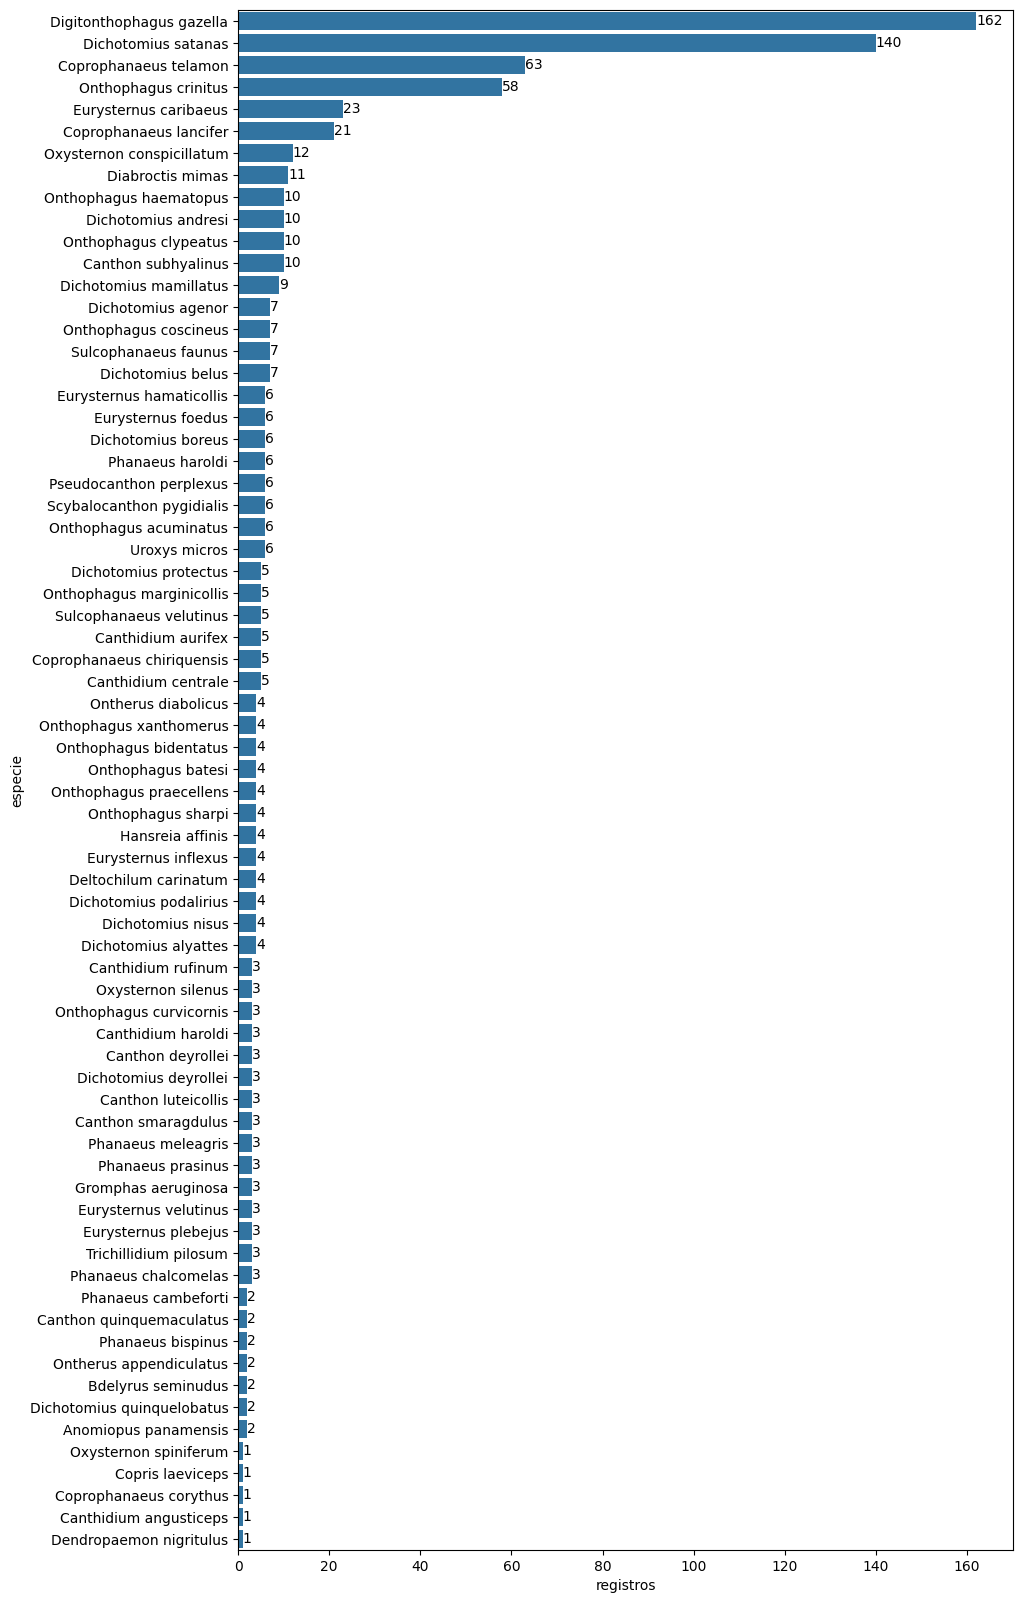

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 20))

ax = sns.barplot(x="registros", y="especie"
          ,data=Registros.loc[Registros['registros'] > 0].sort_values(by="registros", ascending=False),
            )

ax.bar_label(ax.containers[0], fontsize=10);
plt.show()


In [ ]:
Registros.loc[Registros['registros'] > 0].count()

,0
especie,70
registros,70
genero,70


## Agrupar archivos

El siguiente codigo agrupa todos los TSV en una

In [ ]:
import glob

ruta_carpeta = "/content/*.tsv"

archivos_tsv = glob.glob(ruta_carpeta)

df_registros = pd.concat((pd.read_csv(f, sep='\t') for f in archivos_tsv), ignore_index=True)


/tmp/ipykernel_627/2934275966.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_registros = pd.concat((pd.read_csv(f, sep='\t') for f in archivos_tsv), ignore_index=True)


In [ ]:
df_registros.shape[0]

757

In [ ]:
df_registros.duplicated().sum()

np.int64(0)

Obtener genero de las especies

In [ ]:
df_registros['genus'] = df_registros['scientificName'].apply(lambda x: x.split()[0])

Exportacion de datos

In [ ]:
df_registros.to_csv("Datos/Registros_raw.tsv", sep="\t", index=False)

In [ ]:
import pandas as pd

df_registros = pd.read_csv("Datos/Registros_raw.tsv", sep="\t")

In [ ]:
df_registros.shape[0]

757

In [ ]:
df_registros.head()

,scientificName,accession,definition,voucher,genes,authors,title,journal,pubmed
0,Canthidium rufinum,AY131869.1,Canthidium rufinum cytochrome oxidase subunit ...,NaN,"('COI', 'cytochrome oxidase subunit I')","Monaghan,M.T., Inward,D.J., Hunt,T. and Vogler...",A molecular phylogenetic analysis of the Scara...,"Mol. Phylogenet. Evol. 45 (2), 674-692 (2007)",17656114.0
1,Canthidium rufinum,AY131507.1,"Canthidium rufinum 16S ribosomal RNA gene, par...",NaN,"('', '16S ribosomal RNA')","Monaghan,M.T., Inward,D.J., Hunt,T. and Vogler...",A molecular phylogenetic analysis of the Scara...,"Mol. Phylogenet. Evol. 45 (2), 674-692 (2007)",17656114.0
2,Canthidium rufinum,AY131696.1,"Canthidium rufinum 28S ribosomal RNA gene, par...",NaN,"('', '28S ribosomal RNA')","Monaghan,M.T., Inward,D.J., Hunt,T. and Vogler...",A molecular phylogenetic analysis of the Scara...,"Mol. Phylogenet. Evol. 45 (2), 674-692 (2007)",17656114.0
3,Canthidium aurifex,EU162436.1,Canthidium aurifex cytochrome c oxidase subuni...,NaN,"('COI', 'cytochrome c oxidase subunit I')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0
4,Canthidium aurifex,EU162397.1,Canthidium aurifex cytochrome c oxidase subuni...,NaN,"('COII', 'cytochrome c oxidase subunit II')","Emlen,D.J., Marangelo,J., Ball,B. and Cunningh...",Diversity in the weapons of sexual selection: ...,"Evolution 59 (5), 1060-1084 (2005)",16136805.0


In [ ]:
import ast
df_registros['genes_tuple'] = df_registros['genes'].apply(ast.literal_eval)

count = df_registros[
    (df_registros['genes_tuple'].apply(lambda x: x[0] == ''))].shape[0]

print(f"Cantidad de registros sin gen explicito: {count}")

Number of records where the first item of 'genes' is '' and the second is 'cytochrome oxidase subunit I': 446


In [ ]:
count

446

26 articulos incluyen especies que estan en colombia

In [ ]:
df_registros['genus'].nunique()

23

In [ ]:
df_registros.groupby(["title"])["scientificName"].count().sort_values(ascending=False)

,scientificName
title,
Temporal turnover of haplotype diversity in a community of tropical dung beetles,173
Taxonomic reassessment of the genus Dichotomius (Coleoptera:,166
A molecular phylogenetic analysis of the Scarabaeinae (dung beetles),83
Evolutionary history of Coleoptera revealed by extensive sampling of genes and species,81
Diversity in the weapons of sexual selection: horn evolution in the beetle genus Onthophagus (Coleoptera: Scarabaeidae),52
Phylogeny and biogeography of the dung beetle genus Phanaeus (Coleoptera: Scarabaeidae),29
"Molecular Phylogeny of Coprophanaeus (Megaphanaeus) d'Olsoufieff, 1924 (Coleoptera: Scarabaeidae: Scarabaeinae) and the position of",17
Genetic and phenotypic divergence in a dung beetle 50 years after its introduction to Australia,15
Dung beetles of the Mpala Research Centre,14


In [ ]:
df_registros.isna().sum()

,0
scientificName,0
accession,0
definition,0
voucher,144
genes,0
authors,10
title,0
journal,0
pubmed,498
genes_tuple,0


Eliminar registros sin Voucher

In [ ]:
df_clean = df_registros.loc[df_registros['voucher'].notna()]

In [ ]:
df_clean.shape

(613, 11)

eliminar registros sin gene y product

In [ ]:
import ast

df_clean[['gene', 'product']] = (
    df_clean['genes']
    .apply(ast.literal_eval)
    .apply(pd.Series)
)

df_clean[['gene', 'product']] = df_clean[['gene', 'product']].fillna("")

/tmp/ipykernel_627/1754772074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['gene', 'product']] = (
/tmp/ipykernel_627/1754772074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['gene', 'product']] = (
/tmp/ipykernel_627/1754772074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [ ]:
df_clean.isna().sum()

,0
scientificName,0
accession,0
definition,0
voucher,0
genes,0
authors,10
title,0
journal,0
pubmed,486
genes_tuple,0


In [ ]:
df_clean.shape

(613, 13)

In [ ]:
df_clean.groupby(["scientificName"])["genes"].count().sort_values(ascending=False)

,genes
scientificName,
Digitonthophagus gazella,149
Dichotomius satanas,139
Coprophanaeus telamon,60
Onthophagus crinitus,51
Eurysternus caribaeus,20
Coprophanaeus lancifer,18
Canthon subhyalinus,10
Dichotomius andresi,10
Diabroctis mimas,9


In [ ]:
df_clean['genes'].unique()

array(["('', 'cytomchrome c oxidase subunit 1')",
       "('', '18S ribosomal RNA')",
       "('atp6;atp8;cox1;cox2;cox3;cytb;nad1;nad2;nad3;nad4;nad4L;nad5;nad6;rrnL;rrnS;trnA(tgc);trnC(gca);trnD(gtc);trnE(ttc);trnF(gaa);trnG(tcc);trnH(gtg);trnI(gat);trnK(ctt);trnL1(tag);trnL2(taa);trnM(cat);trnN(gtt);trnP(tgg);trnQ(ttg);trnR(tcg);trnS1(tct);trnS2(tga);trnT(tgt);trnV(tac);trnW(tca);trnY(gta)', '12S ribosomal RNA;16S ribosomal RNA;ATP synthase F0 subunit 6;ATP synthase F0 subunit 8;NADH deshydrogenase subunit 1;NADH deshydrogenase subunit 2;NADH deshydrogenase subunit 3;NADH deshydrogenase subunit 4;NADH deshydrogenase subunit 4L;NADH deshydrogenase subunit 5;NADH deshydrogenase subunit 6;cytochrome b;cytochrome c oxidase subunit 1;cytochrome c oxidase subunit 2;cytochrome c oxidase subunit 3;tRNA-Ala;tRNA-Arg;tRNA-Asn;tRNA-Asp;tRNA-Cys;tRNA-Gln;tRNA-Glu;tRNA-Gly;tRNA-His;tRNA-Ile;tRNA-Leu;tRNA-Lys;tRNA-Met;tRNA-Phe;tRNA-Pro;tRNA-Ser;tRNA-Thr;tRNA-Trp;tRNA-Tyr;tRNA-Val')",
       "('CO

In [ ]:
import pandas as pd
import re

mapping = {
    "cytochrome c oxidase subunit i": "cox1",
    "cytochrome oxidase subunit 1": "cox1",
    "cytochrome oxidase subunit i": "cox1",
    "cytochome oxidase subunit i": "cox1",
    "cytomchrome c oxidase subunit 1": "cox1",

    "cytochrome b": "cytb",

    "16s ribosomal rna": "rrnL",
    "12s ribosomal rna": "rrnS",
    "18s ribosomal rna": "18S",
    "28s ribosomal rna": "28S",

    "hormone receptor 38-like protein": "Hr38",
    "glyceraldehyde 3 phosphate dehydrogenase": "Gapdh",
    "frizzled 2": "fz2",
    "f-box protein 11": "Fbx11",
    "embargoed": "emb",
    "elongator complex protein 3": "Elp3",
    "dusky-like protein": "dyl",
    "dopamine 1-like receptor 2": "Dop1R2",
    "dunce": "dnc",
    "dynein heavy chain": "Dhc",
    "diablo": "dblo",
    "calreticulin": "Calr",
    "crinkled": "ck",
    "acetylcholine esterase": "Ace",
    "wntless": "wls",
    "target of rapamycin": "Tor",
    "topoisomerase i": "Top1",
    "topoisomerase 2": "Top2",
    "wingless": "wg",
}

# Normalizar product
product_normalized = (
    df_clean["product"]
    .astype("string")
    .str.strip()                          # espacios al inicio/final
    .str.replace(r"\s+", " ", regex=True) # múltiples espacios -> uno
    .str.lower()                          # ignorar mayúsculas/minúsculas
)

# Aplicar mapping
df_clean["gene_symbol"] = product_normalized.replace(mapping)

/tmp/ipykernel_627/3753110922.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["gene_symbol"] = product_normalized.replace(mapping)


In [ ]:
df_clean.shape

(613, 14)

In [ ]:
df_clean.groupby(["voucher","scientificName"])["scientificName"].count().sort_values(ascending=False)

,,scientificName
voucher,scientificName,
CSR142,Digitonthophagus gazella,81
ZMUM 10087770,Sulcophanaeus velutinus,5
Ont.cat.15.1,Digitonthophagus gazella,5
ZMUM 10087749,Coprophanaeus chiriquensis,5
CEMT00050918,Sulcophanaeus faunus,4
...,...,...
BMNH 679857,Onthophagus clypeatus,1
BMNH 679854,Onthophagus bidentatus,1
BMNH 679823,Eurysternus inflexus,1


In [ ]:
voucher = (df_clean
 .groupby(["voucher","scientificName"]).count().sort_values(by="gene_symbol", ascending=False).reset_index())

In [ ]:
voucher

,voucher,scientificName,accession,definition,genes,authors,title,journal,pubmed,genes_tuple,genus,gene,product,gene_symbol
0,CSR142,Digitonthophagus gazella,81,81,81,81,81,81,81,81,81,81,81,81
1,ZMUM 10087770,Sulcophanaeus velutinus,5,5,5,5,5,5,5,5,5,5,5,5
2,Ont.cat.15.1,Digitonthophagus gazella,5,5,5,5,5,5,5,5,5,5,5,5
3,ZMUM 10087749,Coprophanaeus chiriquensis,5,5,5,5,5,5,5,5,5,5,5,5
4,CEMT00050918,Sulcophanaeus faunus,4,4,4,4,4,4,0,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,BMNH 679857,Onthophagus clypeatus,1,1,1,1,1,1,0,1,1,1,1,1
400,BMNH 679854,Onthophagus bidentatus,1,1,1,1,1,1,0,1,1,1,1,1
401,BMNH 679823,Eurysternus inflexus,1,1,1,1,1,1,0,1,1,1,1,1
402,BMNH 679822,Eurysternus hamaticollis,1,1,1,1,1,1,0,1,1,1,1,1


In [ ]:
voucher[voucher['accession']>5].count()

,0
voucher,1
scientificName,1
accession,1
definition,1
genes,1
authors,1
title,1
journal,1
pubmed,1
genes_tuple,1


In [ ]:
df_clean.groupby(["voucher","scientificName"]).count().sort_values(by="gene_symbol", ascending=False)

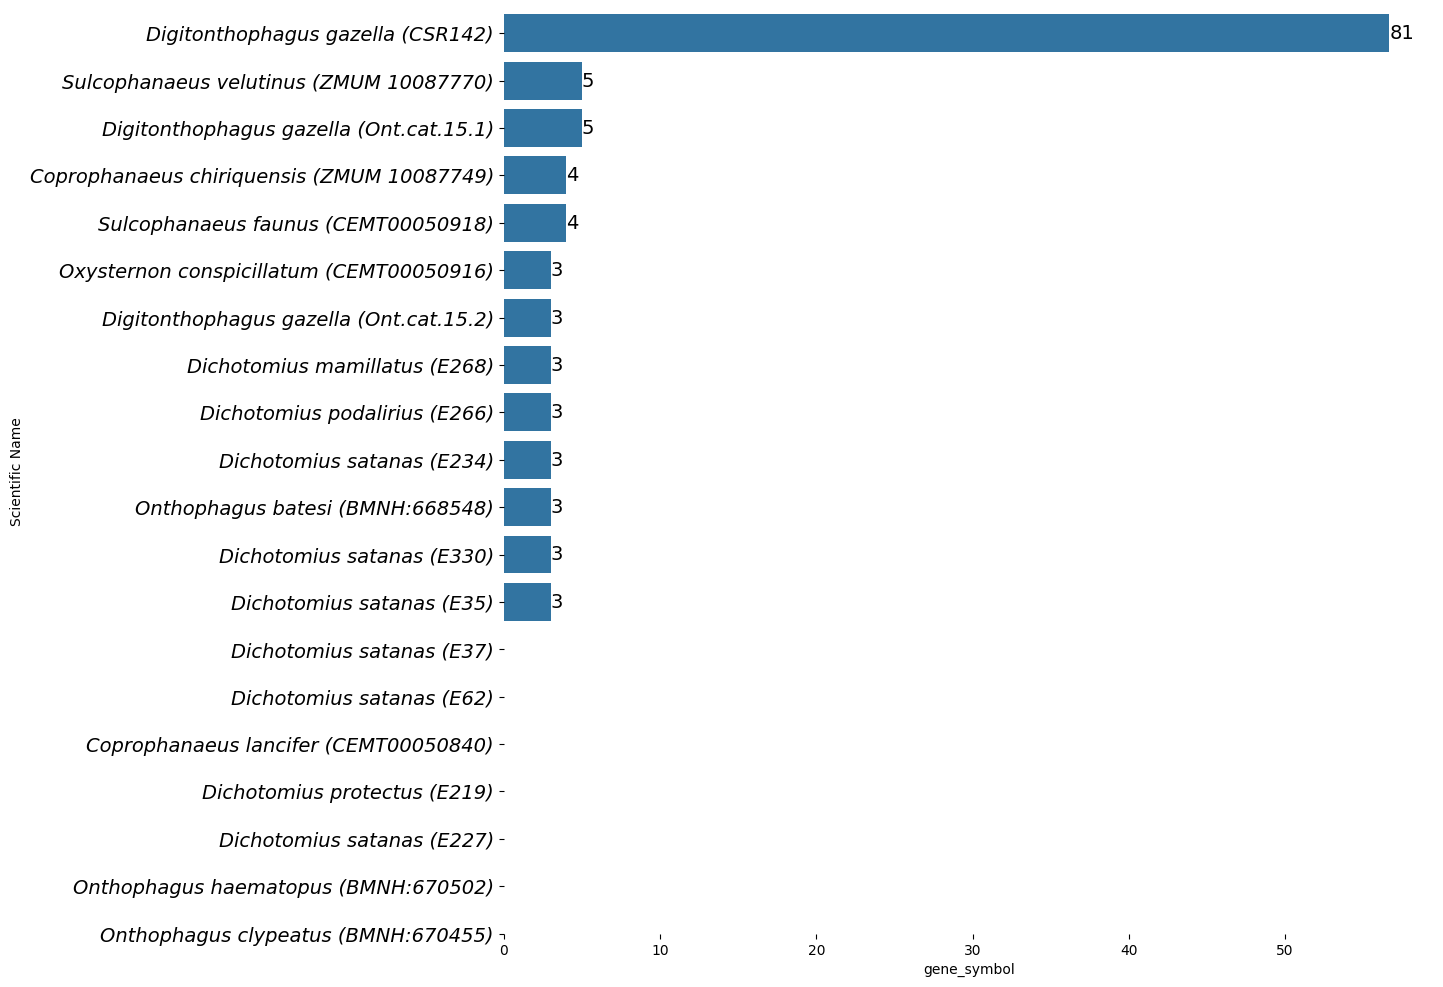

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tomar las primeras 20 filas y resetear índice
plot_data = voucher.head(20).copy().reset_index(drop=True)

# Guardar valor original de la primera fila
actual_first_value = plot_data.loc[0, 'gene_symbol']

# Modificar solo para visualización
plot_data.loc[0, 'gene_symbol'] = 162

# Hacer la figura más alta
fig, ax = plt.subplots(figsize=(12, 12))
sns.barplot(
    y="scientificName",
    x="gene_symbol",
    data=plot_data,
    errorbar=None,
    ax=ax
)

# Etiquetas de las barras
bar_labels = ax.bar_label(
    ax.containers[0],
    fontsize=14
)

# Restaurar etiqueta original de la primera barra
bar_labels[0].set_text(str(actual_first_value))

# Crear etiquetas del eje Y
max_combined_chars = 70

new_y_tick_labels = []

for _, row in plot_data.iterrows():

    scientific_name = str(row['scientificName'])
    voucher_id = str(row['voucher'])

    voucher_part = f" ({voucher_id})"

    available_space_for_name = (
        max_combined_chars - len(voucher_part)
    )

    if len(scientific_name) > available_space_for_name:

        if available_space_for_name > 3:
            display_name = (
                scientific_name[:available_space_for_name - 3]
                + "..."
            )
        else:
            display_name = scientific_name[:available_space_for_name]

    else:
        display_name = scientific_name

    new_y_tick_labels.append(
        display_name + voucher_part
    )

# Aplicar etiquetas
ax.set_yticks(range(len(new_y_tick_labels)))
ax.set_yticklabels(
    new_y_tick_labels,
    fontstyle='italic',
    fontsize=14
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_ylabel("Scientific Name")
ax.set_xlabel("gene_symbol")


plt.show()

In [ ]:
genes = (df_clean
 .groupby(["gene_symbol", "scientificName"])["voucher"].count().sort_values( ascending=False).reset_index()
)

In [ ]:
print(genes[genes['gene_symbol']==''])

Cantidad de registros despues de limpiar

In [ ]:
df_registros.shape[0] - df_clean.shape[0]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# Datos
plot_data = (
    df_clean
    .groupby("title")["scientificName"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(20, 12))

sns.barplot(
    y="title",
    x="scientificName",
    data=plot_data,
    ax=ax
)

# Etiquetas de las barras
ax.bar_label(ax.containers[0], fontsize=16)

# -----------------------------------
# Dividir títulos largos en líneas
# -----------------------------------

max_chars = 70

new_labels = []

for title in plot_data["title"]:
    title = str(title)

    # Divide el texto cada max_chars caracteres
    wrapped = "\n".join(
        textwrap.wrap(
            title,
            width=max_chars,
            break_long_words=False,
            break_on_hyphens=False
        )
    )

    new_labels.append(wrapped)

ax.set_yticks(range(len(new_labels)))
ax.set_yticklabels(new_labels, fontsize=18)

# -----------------------------------
# Estética
# -----------------------------------

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

ax.tick_params(
    axis="y",
    length=0
)

plt.ylabel("Artículo", fontsize=18)
plt.xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
df_clean.groupby(["scientificName"])["gene_symbol"].count().sort_values(ascending=False).head(20)

In [ ]:
df_clean.head()

,scientificName,accession,definition,voucher,genes,authors,title,journal,pubmed,genes_tuple,genus,gene,product,gene_symbol
5,Canthidium aurifex,JQ972582.1,Canthidium aurifex voucher BMNH:900669 cytomch...,BMNH:900669,"('', 'cytomchrome c oxidase subunit 1')","Ensom,T.C. and Vogler,A.P.",Temporal turnover of haplotype diversity in a ...,Unpublished,NaN,"(, cytomchrome c oxidase subunit 1)",Canthidium,,cytomchrome c oxidase subunit 1,cox1
10,Uroxys micros,JQ972218.1,Uroxys micros voucher BMNH:668690 cytomchrome ...,BMNH:668690,"('', 'cytomchrome c oxidase subunit 1')","Ensom,T.C. and Vogler,A.P.",Temporal turnover of haplotype diversity in a ...,Unpublished,NaN,"(, cytomchrome c oxidase subunit 1)",Uroxys,,cytomchrome c oxidase subunit 1,cox1
11,Uroxys micros,JQ972216.1,Uroxys micros voucher BMNH:668688 cytomchrome ...,BMNH:668688,"('', 'cytomchrome c oxidase subunit 1')","Ensom,T.C. and Vogler,A.P.",Temporal turnover of haplotype diversity in a ...,Unpublished,NaN,"(, cytomchrome c oxidase subunit 1)",Uroxys,,cytomchrome c oxidase subunit 1,cox1
12,Uroxys micros,JQ972151.1,Uroxys micros voucher BMNH:668569 cytomchrome ...,BMNH:668569,"('', 'cytomchrome c oxidase subunit 1')","Ensom,T.C. and Vogler,A.P.",Temporal turnover of haplotype diversity in a ...,Unpublished,NaN,"(, cytomchrome c oxidase subunit 1)",Uroxys,,cytomchrome c oxidase subunit 1,cox1
17,Hansreia affinis,JN619191.1,Hansreia affinis voucher BMNH:679751 18S ribos...,BMNH:679751,"('', '18S ribosomal RNA')","Barton,C., Bocak,L., Chesters,D. and Vogler,A.P.",The beetle tree of life updated: DNA taxonomy ...,Unpublished,NaN,"(, 18S ribosomal RNA)",Hansreia,,18S ribosomal RNA,18S


In [ ]:
df_clean[df_clean["genus"]=="Dichotomius"]["gene_symbol"].unique()

<StringArray>
['cox1', '28S', '18S']
Length: 3, dtype: string

In [ ]:
df_clean.groupby(["genus"])["gene_symbol"].nunique().sort_values(ascending=False).head(25)

,gene_symbol
genus,
Digitonthophagus,88
Coprophanaeus,8
Sulcophanaeus,7
Onthophagus,7
Oxysternon,6
Eurysternus,5
Canthon,4
Trichillidium,3
Scybalocanthon,3


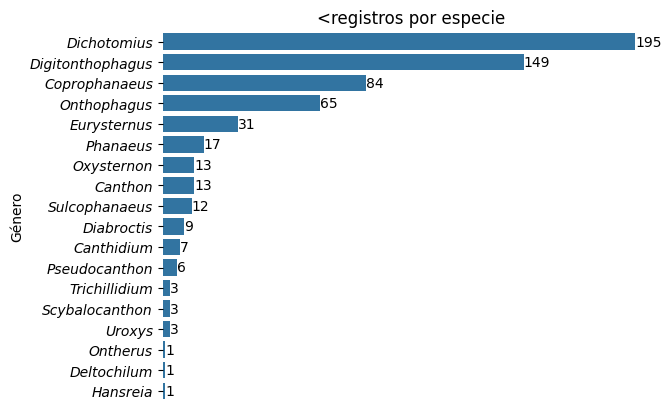

In [ ]:
ax = sns.barplot(y="genus", x="accession"
          ,data=df_clean.groupby(["genus"])["accession"].count().sort_values(ascending=False).head(25).reset_index(),
            )

ax.bar_label(ax.containers[0], fontsize=10);
# Set y-axis tick labels to italic
for tick in ax.get_yticklabels():
    tick.set_fontstyle("italic")

# Hide all chart borders
for spine in ax.spines.values():
    spine.set_visible(False)


plt.title("<registros por especie")
plt.ylabel("Género")
plt.xlabel("")

# Hide x-axis tick labels and ticks
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.show()

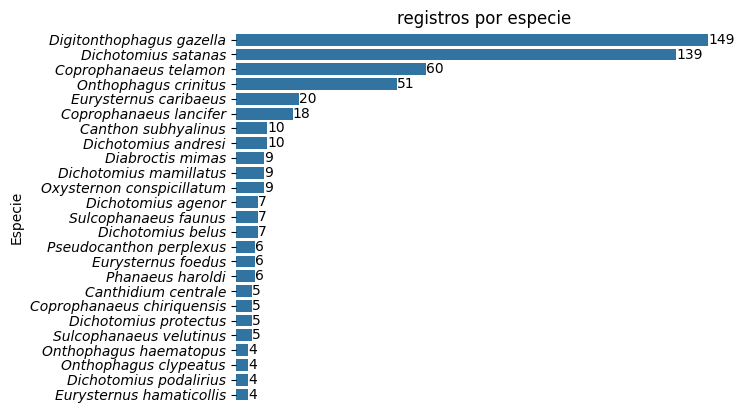

In [ ]:
ax = sns.barplot(y="scientificName", x="accession"
          ,data=df_clean.groupby(["scientificName"])["accession"].count().sort_values(ascending=False).head(25).reset_index(),
            )

ax.bar_label(ax.containers[0], fontsize=10);
# Set y-axis tick labels to italic
for tick in ax.get_yticklabels():
    tick.set_fontstyle("italic")

# Hide all chart borders
for spine in ax.spines.values():
    spine.set_visible(False)


plt.title("registros por especie")
plt.ylabel("Especie")
plt.xlabel("")

# Hide x-axis tick labels and ticks
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.show()

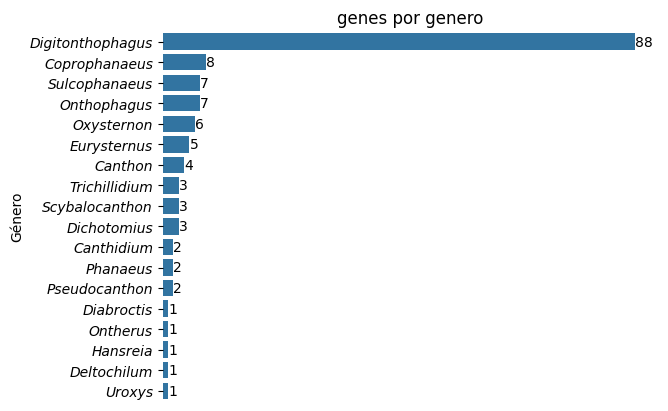

In [ ]:
ax = sns.barplot(y="genus", x="gene_symbol"
          ,data=df_clean.groupby(["genus"])["gene_symbol"].nunique().sort_values(ascending=False).head(25).reset_index(),
            )

ax.bar_label(ax.containers[0], fontsize=10);
# Set y-axis tick labels to italic
for tick in ax.get_yticklabels():
    tick.set_fontstyle("italic")

# Hide all chart borders
for spine in ax.spines.values():
    spine.set_visible(False)


plt.title("genes por genero")
plt.ylabel("Género")
plt.xlabel("")

# Hide x-axis tick labels and ticks
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.show()

In [ ]:
df_result = df_clean.groupby(["scientificName"])["gene_symbol"].count().sort_values(ascending=False).reset_index()
df_result[df_result['gene_symbol']>8].count()

In [ ]:
df_result

In [ ]:
print(df_clean.groupby(["gene_symbol"])["scientificName"].nunique().sort_values(ascending=False).reset_index())

In [ ]:
df_clean['gene_symbol'].unique()

In [ ]:
df_clean.groupby(["voucher"])["scientificName"].nunique().sort_values(ascending=False).head(25).reset_index()

In [ ]:
ax = sns.barplot(
    y="voucher",
    x="scientificName",
    data=df_clean.groupby(["voucher"])["scientificName"]
        .nunique()
        .sort_values(ascending=False)
        .head(25)
        .reset_index()
)

ax.bar_label(ax.containers[0], fontsize=10)

# Cortar nombres largos del eje Y
max_chars = 30

labels = ax.get_yticklabels()

for tick in labels:
    nombre = tick.get_text()

    if len(nombre) > max_chars:
        tick.set_text(nombre[:max_chars] + "...")

    tick.set_fontstyle("italic")

ax.set_yticklabels(labels)


# Ocultar bordes
for spine in ax.spines.values():
    spine.set_visible(False)


plt.ylabel("Gen/genes")
plt.xlabel("")

# Ocultar etiquetas y ticks del eje X
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)

ax.tick_params(axis='x', length=0)

plt.show()

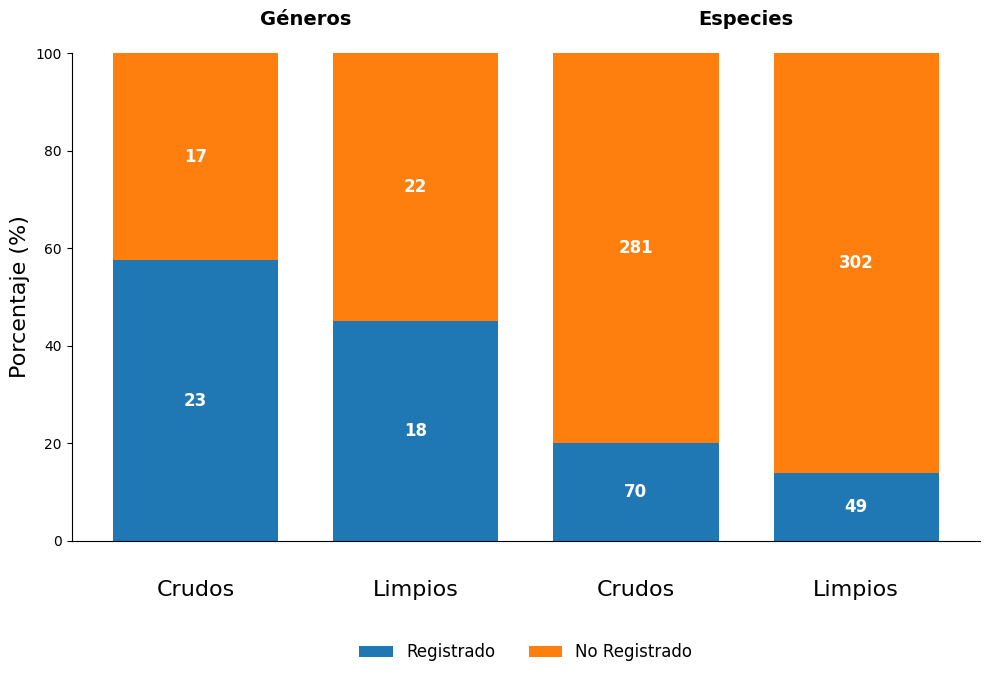

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Datos
# -----------------------------

grupos = ['Géneros', 'Especies']

# Datos crudos
registrado_crudo = np.array([23, 70])
no_registrado_crudo = np.array([17, 281])

# Datos limpios
registrado_limpio = np.array([ 18,49])
no_registrado_limpio = np.array([22,302])


# -----------------------------
# Porcentajes
# -----------------------------

total_crudo = registrado_crudo + no_registrado_crudo
total_limpio = registrado_limpio + no_registrado_limpio

registrado_crudo_pct = registrado_crudo / total_crudo * 100
no_registrado_crudo_pct = no_registrado_crudo / total_crudo * 100

registrado_limpio_pct = registrado_limpio / total_limpio * 100
no_registrado_limpio_pct = no_registrado_limpio / total_limpio * 100


# -----------------------------
# Posiciones
# -----------------------------

pos_crudo = np.array([0, 2])
pos_limpio = np.array([1, 3])

ancho = 0.75


# -----------------------------
# Figura
# -----------------------------

fig, ax = plt.subplots(figsize=(10, 7)) # Ajuste el tamaño de la figura para acomodar el texto más grande

color_presente = 'tab:blue'
color_ausente = 'tab:orange'


# -----------------------------
# Barras crudas
# -----------------------------

ax.bar(
    pos_crudo,
    registrado_crudo_pct,
    ancho,
    color=color_presente,
    label='Registrado'
)

ax.bar(
    pos_crudo,
    no_registrado_crudo_pct,
    ancho,
    bottom=registrado_crudo_pct,
    color=color_ausente,
    label='No Registrado'
)


# -----------------------------
# Barras limpias
# -----------------------------

ax.bar(
    pos_limpio,
    registrado_limpio_pct,
    ancho,
    color=color_presente
)

ax.bar(
    pos_limpio,
    no_registrado_limpio_pct,
    ancho,
    bottom=registrado_limpio_pct,
    color=color_ausente
)


# -----------------------------
# Valores absolutos
# -----------------------------

for i in range(2):

    # Crudos - Presente
    ax.text(
        pos_crudo[i],
        registrado_crudo_pct[i] / 2,
        str(registrado_crudo[i]),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12 # Aumentar tamaño de fuente
    )

    # Crudos - Ausente
    ax.text(
        pos_crudo[i],
        registrado_crudo_pct[i] +
        no_registrado_crudo_pct[i] / 2,
        str(no_registrado_crudo[i]),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12 # Aumentar tamaño de fuente
    )

    # Limpios - Presente
    ax.text(
        pos_limpio[i],
        registrado_limpio_pct[i] / 2,
        str(registrado_limpio[i]),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12 # Aumentar tamaño de fuente
    )

    # Limpios - Ausente
    ax.text(
        pos_limpio[i],
        registrado_limpio_pct[i] +
        no_registrado_limpio_pct[i] / 2,
        str(no_registrado_limpio[i]),
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=12 # Aumentar tamaño de fuente
    )


# -----------------------------
# Géneros / Especies arriba
# -----------------------------

ax.text(
    0.5, 1.05,
    'Géneros',
    transform=ax.get_xaxis_transform(),
    ha='center',
    va='bottom',
    fontsize=14, # Aumentar tamaño de fuente
    fontweight='bold'
)

ax.text(
    2.5, 1.05,
    'Especies',
    transform=ax.get_xaxis_transform(),
    ha='center',
    va='bottom',
    fontsize=14, # Aumentar tamaño de fuente
    fontweight='bold'
)


# -----------------------------
# Crudos / Limpios abajo
# -----------------------------

for i in range(2):

    ax.text(
        pos_crudo[i],
        -0.08,
        'Crudos',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=16 # Aumentar tamaño de fuente
    )

    ax.text(
        pos_limpio[i],
        -0.08,
        'Limpios',
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='top',
        fontsize=16 # Aumentar tamaño de fuente
    )


# -----------------------------
# Ejes
# -----------------------------

ax.set_xticks([])
ax.set_ylim(0, 100)

ax.set_ylabel('Porcentaje (%)', fontsize=16) # Aumentar tamaño de fuente


# -----------------------------
# Leyenda
# -----------------------------

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    fontsize=12 # Aumentar tamaño de fuente
)


# -----------------------------
# Bordes
# -----------------------------

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

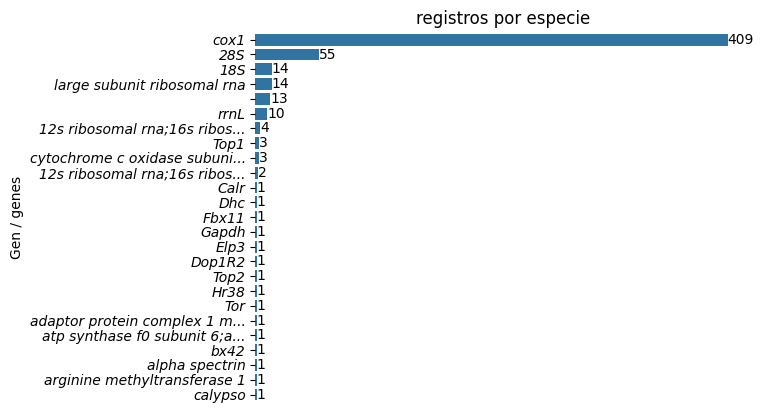

In [ ]:
ax = sns.barplot(y="gene_symbol", x="accession"
          ,data=df_clean.groupby(["gene_symbol"])["accession"].count().sort_values(ascending=False).head(25).reset_index(),
            )

ax.bar_label(ax.containers[0], fontsize=10);
# Set y-axis tick labels to italic

# Truncate y-axis tick labels to 20 characters
max_chars = 30
current_labels = [label.get_text() for label in ax.get_yticklabels()]
new_labels = []
for label in current_labels:
    if len(label) > max_chars:
        new_labels.append(label[:max_chars-3] + "...")
    else:
        new_labels.append(label)

# Set the number of ticks before setting the labels
ax.set_yticks(range(len(new_labels)))
ax.set_yticklabels(new_labels, fontstyle="italic")

# Hide all chart borders
for spine in ax.spines.values():
    spine.set_visible(False)


plt.title("registros por especie")
plt.ylabel("Gen / genes")
plt.xlabel("")

# Hide x-axis tick labels and ticks
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.show()

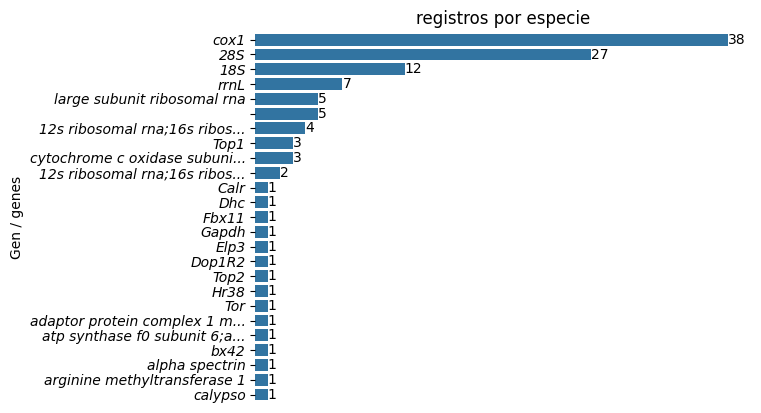

In [ ]:
ax = sns.barplot(y="gene_symbol", x="scientificName"
          ,data=df_clean.groupby(["gene_symbol"])["scientificName"].nunique().sort_values(ascending=False).head(25).reset_index(),
            )

ax.bar_label(ax.containers[0], fontsize=10);
# Set y-axis tick labels to italic

# Truncate y-axis tick labels to 20 characters
max_chars = 30
current_labels = [label.get_text() for label in ax.get_yticklabels()]
new_labels = []
for label in current_labels:
    if len(label) > max_chars:
        new_labels.append(label[:max_chars-3] + "...")
    else:
        new_labels.append(label)

# Set the number of ticks before setting the labels
ax.set_yticks(range(len(new_labels)))
ax.set_yticklabels(new_labels, fontstyle="italic")

# Hide all chart borders
for spine in ax.spines.values():
    spine.set_visible(False)


plt.title("registros por especie")
plt.ylabel("Gen / genes")
plt.xlabel("")

# Hide x-axis tick labels and ticks
for tick_label in ax.get_xticklabels():
    tick_label.set_visible(False)
ax.tick_params(axis='x', length=0)

plt.show()